In [1]:
#### Requirment
# Pandas
# Matplotlib
# Seaborn
# Scikit-learn
# BM_NLP_Classification_WP
# Pickle
# streamlit

# 1. Import the libraries

In [2]:
# Basic libraries
import re
import pandas as pd
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

import BM_NLP_Classification_WP

import importlib
importlib.reload(BM_NLP_Classification_WP)

import pickle


# 2. Load the dataset

In [3]:
# First read attempt
DF = pd.read_csv("twitter_training.csv")

In [4]:
# Preview the first rows to confirm the header problem
DF.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
# Read again with header=None and give the four columns proper names
DF = pd.read_csv("twitter_training.csv",
                 header=None,
                 names=["ID", "Entity", "Sentiment", "Text"])

# This is a multiclass NLP text-classification problem.

In [6]:
# Number of rows and columns in the dataset
DF.shape

(74682, 4)

In [7]:
# Column names, non-null counts and data types
DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [8]:
# Count the missing values in each column
DF.isna().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [9]:
# Count how many rows are exact duplicates
DF.duplicated().sum()

np.int64(2700)

In [10]:
# Work on a copy so the original DataFrame stays untouched
df = DF.copy()

# 3. Explore the data (EDA)

In [11]:
# To find out many tweets of each sentiment do we have
print(df["Sentiment"].value_counts())
print()
print("In percentage:")
print(df["Sentiment"].value_counts(normalize=True).round(3) * 100)

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In percentage:
Sentiment
Negative      30.2
Positive      27.9
Neutral       24.5
Irrelevant    17.4
Name: proportion, dtype: float64


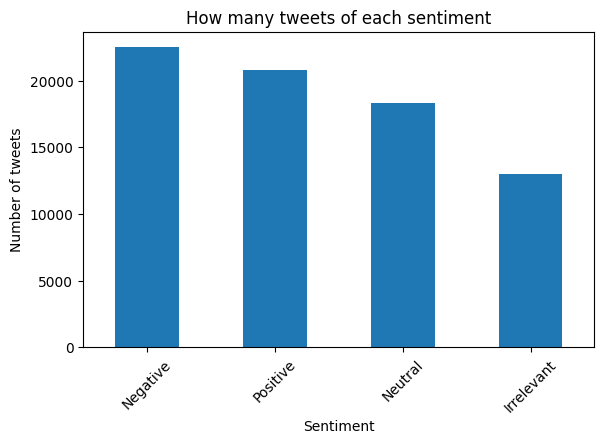

In [12]:
# Bar plot of the sentiment
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("How many tweets of each sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.xticks(rotation=45)

plt.tight_layout(pad=2.0)
plt.show()

Number of Entities: 32


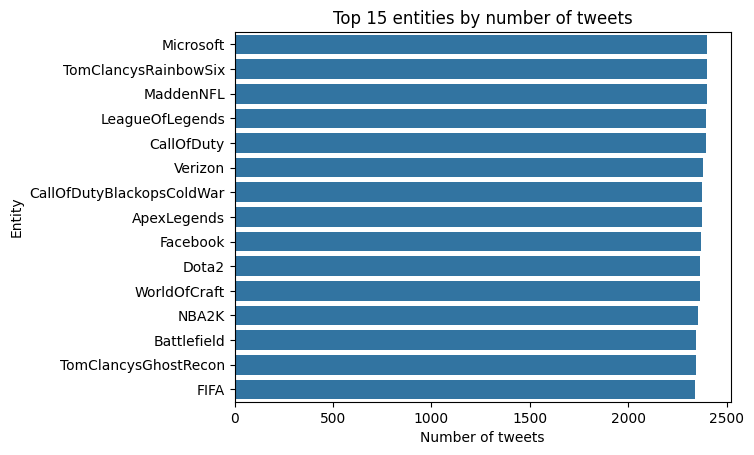

In [13]:
# To find out how many different entities (topics) are there
print("Number of Entities:", df["Entity"].nunique())

# The 15 most common ones
top_entities = df["Entity"].value_counts().head(15)
sns.barplot(x=top_entities.values, y=top_entities.index)
plt.title("Top 15 entities by number of tweets")
plt.xlabel("Number of tweets")
plt.ylabel("Entity")
plt.show()

In [14]:
# Look at a few example tweets for each sentiment
for label in ["Positive", "Negative", "Neutral", "Irrelevant"]:
    print("=" * 60)
    print(label)
    print("=" * 60)
    examples = df[df["Sentiment"] == label]["Text"].dropna().head(3)
    for tweet in examples:
        print(tweet)

Positive
im getting on borderlands and i will murder you all ,
I am coming to the borders and I will kill you all,
im getting on borderlands and i will kill you all,
Negative
the biggest dissappoinment in my life came out a year ago fuck borderlands 3
The biggest disappointment of my life came a year ago.
The biggest disappointment of my life came a year ago.
Neutral
Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it/RMTrgF  
Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it / RMTrgF
Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dfr.it / RMTrgF
Irrelevant
Appreciate the (sonic) concepts / praxis Valenzuela and Landa-Posas thread together in this talk: multimodal listening, soundwalks, borderlands frameworks, participatory action research, and testimonios. . . So many thoughtful and resonant intersections here.. .  
Appreciate the (sound) concepts / practices that Valenzuela and Landa-

# 4. Clean the data

In [15]:
# Remove duplicated rows
df = df.drop_duplicates()

# Remove rows where the tweet text is missing
df = df.dropna(subset=["Text"])

# Reset the row numbers after deleting rows
df = df.reset_index(drop=True)

print("Rows and columns after cleaning:", df.shape)

Rows and columns after cleaning: (71656, 4)


# 4.1 Clean the text itself

In [16]:
# A simple list of stopwords (very common English words)
stopword_text = """
a an the and or but if while of at by for with about against between into through during
before after above below to from up down in out on off over under again further then once
here there all any both each few more most other some such only own same so than too very
is am are was were be been being have has had having do does did doing i me my myself we our
ours you your yours he him his she her hers it its they them their what which who whom this
that these those will would shall should can could may might must
"""

stopwords = set(stopword_text.split())
print("Number of stopwords:", len(stopwords))

Number of stopwords: 110


In [17]:
# Make a function to clean the Text 
def clean_text(text):
    """Take one tweet and return a cleaned version of it."""

    # 1. Make everything lowercase
    text = text.lower()

    # 2. Remove web links
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 3. Remove @mentions (like @netflix)
    text = re.sub(r"@\w+", " ", text)

    # 4. Keep only letters and spaces (removes numbers, emojis, punctuation)
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5. Split into words, drop stopwords and very short words
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]

    # 6. Join the words back into one sentence
    return " ".join(words)

In [18]:
# Quick test on one sentence
sample = "I LOVE @Borderlands 3!!! Best game ever, check http://bl3.com :)"
print("Before:", sample)
print("After :", clean_text(sample))

Before: I LOVE @Borderlands 3!!! Best game ever, check http://bl3.com :)
After : love best game ever check


In [19]:
# Apply the cleaning function to every tweet
df["Clean_Text"] = df["Text"].apply(clean_text)

# Show the original and the cleaned version side by side
df[["Text", "Clean_Text", "Sentiment"]].head(10)

,Text,Clean_Text,Sentiment
0,im getting on borderlands and i will murder yo...,getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,coming borderlands murder,Positive
4,im getting on borderlands 2 and i will murder ...,getting borderlands murder,Positive
5,im getting into borderlands and i can murder y...,getting borderlands murder,Positive
6,So I spent a few hours making something for fu...,spent hours making something fun don know huge...,Positive
7,So I spent a couple of hours doing something f...,spent couple hours something fun don know huge...,Positive
8,So I spent a few hours doing something for fun...,spent hours something fun don know huge border...,Positive
9,So I spent a few hours making something for fu...,spent hours making something fun don know huge...,Positive


In [20]:
# Find out empty tweets (for example a tweet with only a link),
empty_rows = (df["Clean_Text"].str.strip() == "").sum()
print("Empty tweets after cleaning:", empty_rows)

Empty tweets after cleaning: 1688


In [21]:
# Removing these rows because there is nothing left to learn
df = df[df["Clean_Text"].str.strip() != ""].reset_index(drop=True)
print("Final number of rows:", df.shape[0])

Final number of rows: 69968


In [22]:
# Find out how long are the tweets?
def count_words(text):
    return len(text.split())

df["word_count"] = df["Clean_Text"].apply(count_words)

In [23]:
# Basic statistics of the tweet length (mean, min, max, quartiles)
df["word_count"].describe()

count    69968.000000
mean        11.063086
std          7.571278
min          1.000000
25%          5.000000
50%          9.000000
75%         15.000000
max        129.000000
Name: word_count, dtype: float64